In [1]:
!uv sync

Resolved 17 packages in 22ms
Audited 16 packages in 4ms


In [2]:
import jax
import jax.numpy as jnp
from jax import jit, lax
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)  # float64 for mass conservation
print(f"JAX {jax.__version__}, devices: {jax.devices()}")

JAX 0.10.0, devices: [CpuDevice(id=0)]


In [3]:
# D2Q9 lattice — Python lists for static values, JAX array for weights only
w  = jnp.array([4/9, 1/9, 1/9, 1/9, 1/9, 1/36, 1/36, 1/36, 1/36])
ex = [0, 1, 0, -1,  0, 1, -1, -1,  1]
ey = [0, 0, 1,  0, -1, 1,  1, -1, -1]
opp = [0, 3, 4, 1, 2, 7, 8, 5, 6]
cs2 = 1.0 / 3.0

# JAX arrays only needed for momentum sums (einsum-style)
ex_jnp = jnp.array(ex, dtype=jnp.float64)
ey_jnp = jnp.array(ey, dtype=jnp.float64)

In [ ]:
# Domain
Nx, Ny = 200, 200

# Droplet: 100 μm diameter → R = 50 lu (if dx = 1 μm)
R = 50.0

# Phase-field interface
W = 3.0                         # interface width (lattice units)
sigma = 0.01                    # surface tension (lattice units)
beta  = 3.0 * sigma / W
kappa = 6.0 * sigma * W

# Equal-density, equal-viscosity (simplest stable case)
rho0 = 1.0
nu   = 1.0 / 6.0               # kinematic viscosity
tau_f = 3.0 * nu + 0.5         # = 1.0

# Cahn-Hilliard mobility
Gamma_ch = 1.0
M_ch     = 0.01

# --- Physical-to-lattice pressure conversion ---
# HFE-7500: rho=1614 kg/m³, nu=7.68e-7 m²/s
dx_phys = 1e-6  # 1 μm per lattice unit
nu_phys = 7.68e-7
rho_phys = 1614.0
dt_phys = nu * dx_phys**2 / nu_phys
conv_p = rho_phys * (dx_phys / dt_phys)**2  # Pa per (rho_lu * cs²)

dp_100mbar = 100.0 * 100.0  # 100 mbar → 10000 Pa
drho_100mbar = dp_100mbar / (cs2 * conv_p)
u_est = Ny * drho_100mbar * cs2 / (8.0 * nu)

print(f"Physical mapping: dx={dx_phys*1e6:.0f} μm, dt={dt_phys:.2e} s")
print(f"100 mbar → Δρ_lu={drho_100mbar:.4f}, estimated u_max={u_est:.1f} lu")
print(f"⚠ 100 mbar over 200 μm is too steep for LBM (Ma >> 1).")
print(f"  Real microfluidics uses 100 mbar over ~mm-cm, not 200 μm.")
print()

# Use a safe lattice pressure that gives Ma < 0.1
drho = 0.001
rho_in  = rho0 + drho / 2.0   # inlet (top, y=Ny-1)
rho_out = rho0 - drho / 2.0   # outlet (bottom, y=0)
dp_phys = drho * cs2 * conv_p

print(f"Using safe Δρ={drho:.4f} → ΔP={dp_phys:.2f} Pa = {dp_phys/100:.3f} mbar")
print(f"  rho_in={rho_in:.4f}  rho_out={rho_out:.4f}")
print(f"  Estimated max velocity: ~{Ny*drho*cs2/(8*nu):.3f} lu (Ma≈{Ny*drho*cs2/(8*nu)/0.577:.3f})")

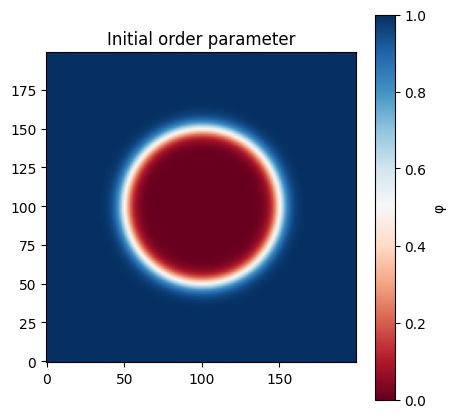

phi range: [0.000000, 1.000000]
Total phi mass: 32052.999570


In [25]:
x = jnp.arange(Nx, dtype=jnp.float64)
y = jnp.arange(Ny, dtype=jnp.float64)
X, Y = jnp.meshgrid(x, y, indexing='ij')

xc, yc = Nx / 2.0, Ny / 2.0
r = jnp.sqrt((X - xc)**2 + (Y - yc)**2)

# phi=1 outside (oil), phi=0 inside (droplet)
phi0 = 0.5 * (1.0 + jnp.tanh((r - R) / (2.0 * W)))

plt.figure(figsize=(5, 5))
plt.imshow(phi0.T, origin='lower', cmap='RdBu', vmin=0, vmax=1)
plt.colorbar(label='φ')
plt.title('Initial order parameter')
plt.show()

print(f"phi range: [{phi0.min():.6f}, {phi0.max():.6f}]")
print(f"Total phi mass: {phi0.sum():.6f}")

In [26]:
@jit
def compute_laplacian(field):
    lap = jnp.zeros_like(field)
    for i in range(1, 9):
        lap += w[i] * jnp.roll(jnp.roll(field, -ex[i], axis=0), -ey[i], axis=1)
    return (2.0 / cs2) * (lap - (1.0 - w[0]) * field)

@jit
def compute_gradient(field):
    gx = jnp.zeros_like(field)
    gy = jnp.zeros_like(field)
    for i in range(1, 9):
        shifted = jnp.roll(jnp.roll(field, -ex[i], axis=0), -ey[i], axis=1)
        gx += w[i] * ex[i] * shifted
        gy += w[i] * ey[i] * shifted
    return gx / cs2, gy / cs2

@jit
def compute_divergence(Fx, Fy):
    """Conservative isotropic divergence. Sums to zero over periodic domain."""
    div = jnp.zeros_like(Fx)
    for i in range(1, 9):
        sx = jnp.roll(jnp.roll(Fx, -ex[i], axis=0), -ey[i], axis=1)
        sy = jnp.roll(jnp.roll(Fy, -ex[i], axis=0), -ey[i], axis=1)
        div += w[i] * (ex[i] * sx + ey[i] * sy)
    return div / cs2

@jit
def chem_potential(phi, lap_phi):
    return 2.0 * beta * phi * (1.0 - phi) * (1.0 - 2.0 * phi) - kappa * lap_phi

@jit
def feq_fn(rho, ux, uy):
    eu = ux[..., None] * ex_jnp + uy[..., None] * ey_jnp
    usq = ux**2 + uy**2
    return w * rho[..., None] * (1.0 + eu/cs2 + eu**2/(2.0*cs2**2) - usq[..., None]/(2.0*cs2))

@jit
def forcing_guo(ux, uy, Fx, Fy):
    eu = ux[..., None] * ex_jnp + uy[..., None] * ey_jnp
    return (1.0 - 0.5/tau_f) * w * (
        (ex_jnp - ux[..., None]) * Fx[..., None] / cs2
        + (ey_jnp - uy[..., None]) * Fy[..., None] / cs2
        + eu / cs2**2 * (ex_jnp * Fx[..., None] + ey_jnp * Fy[..., None])
    )

@jit
def stream(f):
    return jnp.stack([
        jnp.roll(jnp.roll(f[..., i], ex[i], axis=0), ey[i], axis=1)
        for i in range(9)
    ], axis=-1)

In [ ]:
# === Boundary Conditions (Zou-He pressure BC) ===
# Top (y=Ny-1): inlet, known rho_in, oil enters flowing downward
# Bottom (y=0):  outlet, known rho_out, oil exits downward
# Left/Right (x): periodic (handled by jnp.roll)

@jit
def apply_zou_he(f):
    """Apply Zou-He pressure BCs at top (inlet) and bottom (outlet)."""
    
    # --- Bottom outlet (y=0): unknown f_2, f_5, f_6 (pointing up) ---
    # Known at y=0: f_0[:,0], f_1[:,0], f_3[:,0], f_4[:,0], f_7[:,0], f_8[:,0]
    f0_ = f[:, 0, 0]
    f1_ = f[:, 0, 1]
    f3_ = f[:, 0, 3]
    f4_ = f[:, 0, 4]
    f7_ = f[:, 0, 7]
    f8_ = f[:, 0, 8]
    
    uy_out = 1.0 - (f0_ + f1_ + f3_ + 2.0*(f4_ + f7_ + f8_)) / rho_out
    
    f = f.at[:, 0, 2].set(f4_ + (2.0/3.0)*rho_out*uy_out)
    f = f.at[:, 0, 5].set(f7_ - 0.5*(f1_ - f3_) + (1.0/6.0)*rho_out*uy_out)
    f = f.at[:, 0, 6].set(f8_ + 0.5*(f1_ - f3_) + (1.0/6.0)*rho_out*uy_out)
    
    # --- Top inlet (y=Ny-1): unknown f_4, f_7, f_8 (pointing down) ---
    # Known at y=Ny-1: f_0[:,-1], f_1[:,-1], f_3[:,-1], f_2[:,-1], f_5[:,-1], f_6[:,-1]
    f0_ = f[:, -1, 0]
    f1_ = f[:, -1, 1]
    f3_ = f[:, -1, 3]
    f2_ = f[:, -1, 2]
    f5_ = f[:, -1, 5]
    f6_ = f[:, -1, 6]
    
    uy_in = -1.0 + (f0_ + f1_ + f3_ + 2.0*(f2_ + f5_ + f6_)) / rho_in
    
    f = f.at[:, -1, 4].set(f2_ - (2.0/3.0)*rho_in*uy_in)
    f = f.at[:, -1, 7].set(f5_ - 0.5*(f1_ - f3_) - (1.0/6.0)*rho_in*uy_in)
    f = f.at[:, -1, 8].set(f6_ + 0.5*(f1_ - f3_) - (1.0/6.0)*rho_in*uy_in)
    
    return f

@jit
def apply_phi_bc(phi):
    """Inlet: pure oil (phi=1). Outlet: zero-gradient extrapolation."""
    phi = phi.at[:, -1].set(1.0)       # top inlet: oil
    phi = phi.at[:, 0].set(phi[:, 1])  # bottom outlet: copy from interior
    return phi

print("BC functions defined: apply_zou_he (pressure), apply_phi_bc (phase field)")
print(f"  Inlet  (top):    rho_in={rho_in:.4f}, phi=1 (oil)")
print(f"  Outlet (bottom): rho_out={rho_out:.4f}, phi=zero-gradient")

In [ ]:
@jit
def step(state):
    f, phi = state
    
    # Apply phi BCs before stencils (so gradients see correct boundary values)
    phi = apply_phi_bc(phi)
    
    # Phase field operators
    lap_phi = compute_laplacian(phi)
    gx, gy  = compute_gradient(phi)
    mu      = chem_potential(phi, lap_phi)
    
    # Surface tension force
    Fx = mu * gx
    Fy = mu * gy
    
    # Velocity from LBM
    rho = jnp.sum(f, axis=-1)
    ux = (jnp.sum(f * ex_jnp, axis=-1) + 0.5 * Fx) / rho
    uy = (jnp.sum(f * ey_jnp, axis=-1) + 0.5 * Fy) / rho
    
    # LBM collision + streaming
    feq = feq_fn(rho, ux, uy)
    Fi  = forcing_guo(ux, uy, Fx, Fy)
    f   = f - (f - feq) / tau_f + Fi
    f   = stream(f)
    
    # Apply Zou-He pressure BCs (overwrite unknown dists at inlet/outlet)
    f = apply_zou_he(f)
    
    # Cahn-Hilliard update
    lap_mu   = compute_laplacian(mu)
    div_flux = compute_divergence(phi * ux, phi * uy)
    phi      = phi - div_flux + M_ch * lap_mu
    
    # Apply phi BCs after update
    phi = apply_phi_bc(phi)
    
    return (f, phi)

In [ ]:
# Initialize with linear pressure (density) gradient for faster convergence
rho_init = rho_out + (rho_in - rho_out) * Y / (Ny - 1.0)  # linear: rho_out at y=0, rho_in at y=Ny-1
ux0 = jnp.zeros((Nx, Ny))
uy0 = jnp.zeros((Nx, Ny))

f0 = feq_fn(rho_init, ux0, uy0)
phi0_flow = apply_phi_bc(phi0)

print(f"Initial rho: [{rho_init.min():.4f}, {rho_init.max():.4f}]")
print(f"Initial phi mass: {phi0_flow.sum():.2f}")

# JIT warmup
state = (f0, phi0_flow)
state = step(state)
print("JIT compiled.")

# Reset and run
state = (f0, phi0_flow)

def scan_body(state, _):
    return step(state), None

import time
N_steps = 10000
t0 = time.time()
state, _ = lax.scan(scan_body, state, None, length=N_steps)
state[0].block_until_ready()
t1 = time.time()

f_final, phi_final = state
print(f"Done in {t1-t0:.2f}s ({N_steps/(t1-t0):.0f} steps/s)")
print(f"phi range: [{phi_final.min():.6f}, {phi_final.max():.6f}]")

In [ ]:
rho_final = jnp.sum(f_final, axis=-1)
ux_final = jnp.sum(f_final * ex_jnp, axis=-1) / rho_final
uy_final = jnp.sum(f_final * ey_jnp, axis=-1) / rho_final
vel_mag = jnp.sqrt(ux_final**2 + uy_final**2)

# Droplet tracking
mask = (phi_final < 0.5).astype(jnp.float64)
droplet_area = mask.sum()
has_droplet = droplet_area > 0

print("=" * 50)
print("FLOW TEST — 10k STEPS")
print("=" * 50)
print(f"Max |u|:  {vel_mag.max():.4e}   Ma={vel_mag.max()/0.577:.4f}")
print(f"Mean uy:  {uy_final[:, Ny//2].mean():.4e}  (midplane, should be < 0 = downward)")
print(f"rho range: [{rho_final.min():.6f}, {rho_final.max():.6f}]")
print(f"phi range: [{phi_final.min():.6f}, {phi_final.max():.6f}]")
print(f"Droplet area: {droplet_area:.0f} (initial: {(phi0 < 0.5).sum():.0f})")
if has_droplet:
    cx = jnp.sum(X * mask) / mask.sum()
    cy = jnp.sum(Y * mask) / mask.sum()
    print(f"Droplet center: ({cx:.1f}, {cy:.1f})")
else:
    print("Droplet: gone (phi > 0.5 everywhere)")

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# φ field
im0 = axes[0].imshow(phi_final.T, origin='lower', cmap='RdBu', vmin=0, vmax=1)
axes[0].set_title('φ (oil=1, droplet=0)')
plt.colorbar(im0, ax=axes[0])

# Density (pressure) field
im1 = axes[1].imshow(rho_final.T, origin='lower', cmap='viridis')
axes[1].set_title('ρ (pressure ∝ ρ·cs²)')
plt.colorbar(im1, ax=axes[1])

# y-velocity (flow direction)
im2 = axes[2].imshow(uy_final.T, origin='lower', cmap='coolwarm',
                       vmin=-vel_mag.max(), vmax=vel_mag.max())
axes[2].set_title('u_y (downward = negative)')
plt.colorbar(im2, ax=axes[2])

# Velocity magnitude
im3 = axes[3].imshow(vel_mag.T, origin='lower', cmap='hot')
axes[3].set_title(f'|u| (max={vel_mag.max():.2e})')
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

# Velocity profile at midplane x=Nx/2
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(uy_final[Nx//2, :], jnp.arange(Ny), 'b-', lw=2)
ax.set_xlabel('u_y (lattice units)')
ax.set_ylabel('y (lattice units)')
ax.set_title('Velocity profile at x=Nx/2')
ax.axvline(0, color='k', ls='--', alpha=0.3)
ax.axhline(Ny-1, color='r', ls=':', label='inlet (top)')
ax.axhline(0, color='g', ls=':', label='outlet (bottom)')
ax.legend()
plt.show()